In [10]:
import torch 

In [11]:
x_data = [1.0, 2.0, 3.0]
y_data = [2.0, 4.0, 6.0]

w = torch.tensor([1.0])
w.requires_grad_(True) # 开启反向传播，默认False

def forward(x):
    return x * w # ==> tensor([x]) * tensor([w])

def loss(x, y):
    y_pred = forward(x)
    return (y_pred - y) ** 2

loss_list = []
w_list = []
print("Predict (before training) ", 4, forward(4).item()) # .item() 如果是一个标量则得到是一个具体的数值
                                                          # a = tensor([3]) ==> a.item() == 3
for epoch in range(100): # 迭代100次
    for x, y in zip(x_data, y_data):
        l = loss(x,y) # 计算损失函数
        l.backward() # 反向求导，链式计算
        print("\tgrad: ", x, y, w.grad.item()) # 得到梯度的数值
        w.data = w. data - 0.01 * w.grad.data # .data 不涉及计算图的产生
        w_list.append(w.item())
        # print(w.grad)
        w.grad.data.zero_() # zero_() 将链清空，防止二次叠加求导
        # print(w.grad)
        loss_list.append(l.item())
    print("progress: ", epoch, l.item()) # 得到损失值的数值
print("Predict (after training) ", 4, forward(4).item()) # 预测


Predict (before training)  4 4.0
	grad:  1.0 2.0 -2.0
	grad:  2.0 4.0 -7.840000152587891
	grad:  3.0 6.0 -16.228801727294922
progress:  0 7.315943717956543
	grad:  1.0 2.0 -1.478623867034912
	grad:  2.0 4.0 -5.796205520629883
	grad:  3.0 6.0 -11.998146057128906
progress:  1 3.9987640380859375
	grad:  1.0 2.0 -1.0931644439697266
	grad:  2.0 4.0 -4.285204887390137
	grad:  3.0 6.0 -8.870372772216797
progress:  2 2.1856532096862793
	grad:  1.0 2.0 -0.8081896305084229
	grad:  2.0 4.0 -3.1681032180786133
	grad:  3.0 6.0 -6.557973861694336
progress:  3 1.1946394443511963
	grad:  1.0 2.0 -0.5975041389465332
	grad:  2.0 4.0 -2.3422164916992188
	grad:  3.0 6.0 -4.848389625549316
progress:  4 0.6529689431190491
	grad:  1.0 2.0 -0.4417421817779541
	grad:  2.0 4.0 -1.7316293716430664
	grad:  3.0 6.0 -3.58447265625
progress:  5 0.35690122842788696
	grad:  1.0 2.0 -0.3265852928161621
	grad:  2.0 4.0 -1.2802143096923828
	grad:  3.0 6.0 -2.650045394897461
progress:  6 0.195076122879982
	grad:  1.0 2.0 

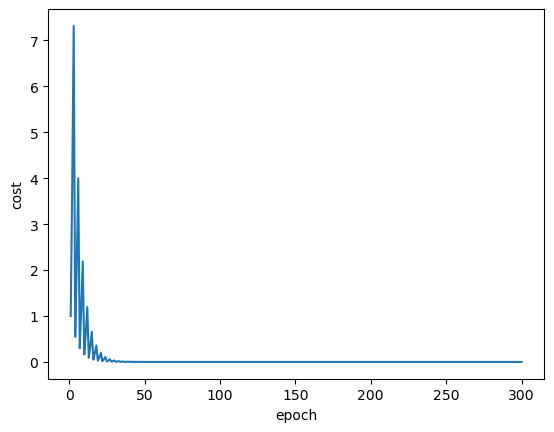

In [12]:
import matplotlib.pyplot as plt

plt.plot(range(1,301), loss_list)
plt.ylabel("cost")
plt.xlabel("epoch")
plt.show()
